<a href="https://colab.research.google.com/github/ksailesh/housing_price_project/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Read the Datasets

In [1]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive/')

df_enriched_features_file_path = '/content/drive/MyDrive/Colab Notebooks/df_enriched_features.pkl'
df_without_enriched_features_file_path = '/content/drive/MyDrive/Colab Notebooks/df_without_enriched_features.pkl'
try:
  df_enriched_features = pd.read_pickle(df_enriched_features_file_path)
  display(df_enriched_features.dtypes)
  df_without_enriched_features = pd.read_pickle(df_without_enriched_features_file_path)
  display(df_without_enriched_features.dtypes)
  print("Successfully loaded the pickle files.")
except FileNotFoundError:
  print(f"Error: File not found at {df_enriched_features_file_path}. Please check the file path.")
  print(f"Error: File not found at {df_without_enriched_features_file_path}. Please check the file path.")
except Exception as e:
  print(f"An error occurred: {e}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,0
longitude,float64
latitude,float64
housing_median_age,int64
total_rooms,int64
total_bedrooms,Int64
population,int64
households,int64
median_income,float64
median_house_value,int64
rooms_per_household,float64


,0
longitude,float64
latitude,float64
housing_median_age,int64
total_rooms,int64
total_bedrooms,Int64
population,int64
households,int64
median_income,float64
median_house_value,int64
ocean_proximity_INLAND,bool


Successfully loaded the pickle files.


# 1a. Neural Network Model - Version 1


In [2]:
# Build the neural network model to predict the housing price using df_enriched_features dataframe

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import tensorflow.keras.backend as K

# df_enriched_features = df_enriched_features[df_enriched_features['median_house_value'] < 500000]

# Assuming 'median_house_value' is the target variable
X = df_enriched_features.drop('median_house_value', axis=1)
y = df_enriched_features['median_house_value']
# X = df_without_enriched_features.drop('median_house_value', axis=1)
# y = df_without_enriched_features['median_house_value']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
# scaler = StandardScaler()
# scaler = MinMaxScaler()
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for regression
])

def rmse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return K.sqrt(K.mean(K.square(y_true - y_pred)))

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=[rmse]) # Mean Squared Error and Root Mean Squared Error
# model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Mean Squared Error and Mean Absolute Error

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 56075350016.0000 - rmse: 235898.3906 - val_loss: 51269373952.0000 - val_rmse: 224969.1719
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 48481042432.0000 - rmse: 218899.2656 - val_loss: 36995969024.0000 - val_rmse: 190492.8281
Epoch 3/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 35215769600.0000 - rmse: 186204.3906 - val_loss: 29212254208.0000 - val_rmse: 168008.8125
Epoch 4/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 29094506496.0000 - rmse: 167616.1875 - val_loss: 24556675072.0000 - val_rmse: 152959.9531
Epoch 5/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23412707328.0000 - rmse: 149775.2344 - val_loss: 21050181632.0000 - val_rmse: 141237.2969
Epoch 6/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 20258220032.0000 - rmse: 138940.0000 - val_loss: 18040426496.0000 - val_rmse: 130666.2734
Epoch 7/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 16689862656.0000 - rmse: 125997.7578 - v

# 1b. Evaluate Model Performance

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4006254848.0000 - rmse: 62224.7148
Root Mean Squared Error on test set: 62778.91796875
loss on test set: 4092765440.0
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


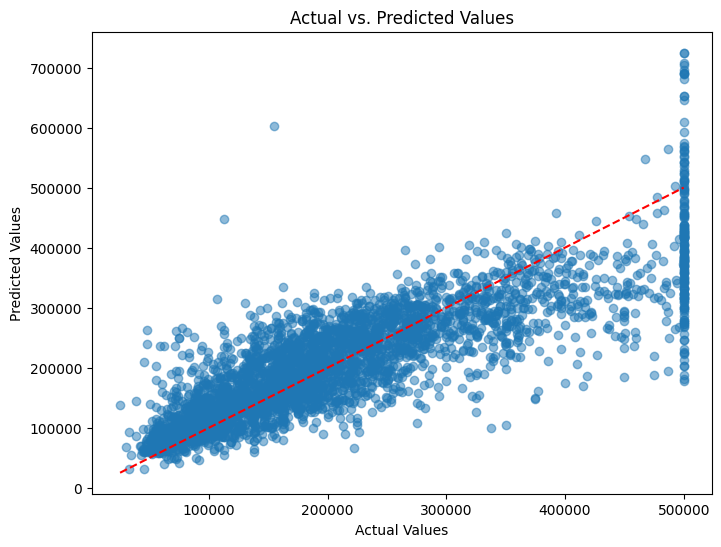

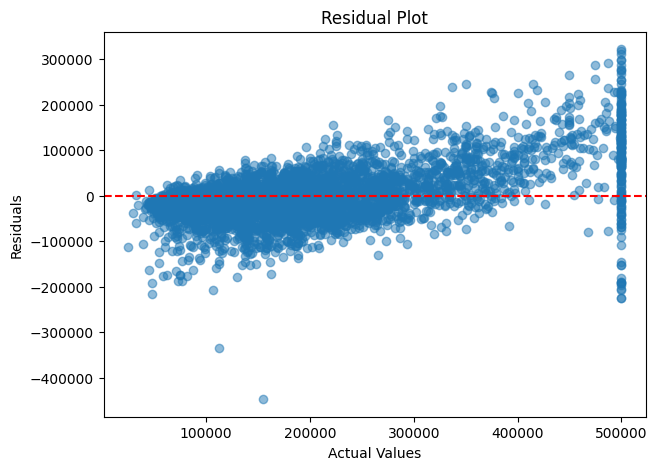

In [3]:
# Evaluate the model
# loss, mae = model.evaluate(X_test, y_test)
# print(f"Mean Absolute Error on test set: {mae}")
loss, rmse = model.evaluate(X_test, y_test)
print(f"Root Mean Squared Error on test set: {rmse}")
print(f"loss on test set: {loss}")

# Compare actual and predicted values using scatter plot
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()

# Reshape y_pred to be 1-dimensional
y_pred = y_pred.flatten()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='dashed')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 2a. Neural Network Model - Version 2

In [4]:
# Build the neural network model to predict the housing price using df_enriched_features dataframe

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import tensorflow.keras.backend as K

# df_enriched_features = df_enriched_features[df_enriched_features['median_house_value'] < 500000]

df_enriched_features.loc[:, 'income_x_population'] = df_enriched_features['median_income'] * df_enriched_features['population_per_household']
df_enriched_features.loc[:, 'pop_x_bedroom_ratio'] = df_enriched_features['population_per_household'] * df_enriched_features['bedrooms_per_room']
df_enriched_features.loc[:, 'rooms_x_bedrooms'] = df_enriched_features['rooms_per_household'] * df_enriched_features['bedrooms_per_household']
df_enriched_features.loc[:, 'income_x_ocean_proximity'] = df_enriched_features['median_income'] * df_enriched_features['ocean_proximity_INLAND']
df_enriched_features.loc[:, 'ocean_x_rooms'] = df_enriched_features['ocean_proximity_NEAR OCEAN'] * df_enriched_features['rooms_per_household']
df_enriched_features.loc[:, 'ocean_x_rooms'] = df_enriched_features['ocean_proximity_NEAR OCEAN'] * df_enriched_features['rooms_per_household']

# Define the independent and dependent variables
# X = df_enriched_features
X = df_enriched_features[[
                          'longitude', 'latitude',
                          # 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'pop_x_bedroom_ratio',
                          # 'income_per_population',  'rooms_x_bedrooms',  'ocean_proximity_INLAND', 'income_x_population',
                          'housing_median_age', 'households', 'median_income', 'ocean_proximity_NEAR BAY', 'income_x_ocean_proximity',
                          'bedrooms_per_room', 'population_per_household', 'bedrooms_per_household', 'ocean_x_rooms'
                          ]]

# Assuming 'median_house_value' is the target variable
X = df_enriched_features.drop('median_house_value', axis=1)
y = df_enriched_features['median_house_value']
# X = df_without_enriched_features.drop('median_house_value', axis=1)
# y = df_without_enriched_features['median_house_value']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
# scaler = StandardScaler()
# scaler = MinMaxScaler()
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for regression
])

def rmse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return K.sqrt(K.mean(K.square(y_true - y_pred)))

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=[rmse]) # Mean Squared Error and Root Mean Squared Error
# model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Mean Squared Error and Mean Absolute Error

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 55409729536.0000 - rmse: 234309.2500 - val_loss: 49567178752.0000 - val_rmse: 221209.5938
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45043036160.0000 - rmse: 210918.8125 - val_loss: 33832112128.0000 - val_rmse: 181911.2969
Epoch 3/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30479849472.0000 - rmse: 172232.5781 - val_loss: 26006710272.0000 - val_rmse: 158031.2812
Epoch 4/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24775968768.0000 - rmse: 154323.2656 - val_loss: 22210607104.0000 - val_rmse: 145296.8906
Epoch 5/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 19957934080.0000 - rmse: 138956.6250 - val_loss: 19425384448.0000 - val_rmse: 135905.6562
Epoch 6/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17853372416.0000 - rmse: 130964.8125 - val_loss: 17078416384.0000 - val_rmse: 127268.7031
Epoch 7/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 15552644096.0000 - rmse: 122727.7891 - val_loss: 14

# 2b. Evaluate Model Performance

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3960747264.0000 - rmse: 61925.2422
Root Mean Squared Error on test set: 62442.03515625
loss on test set: 4037030144.0
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


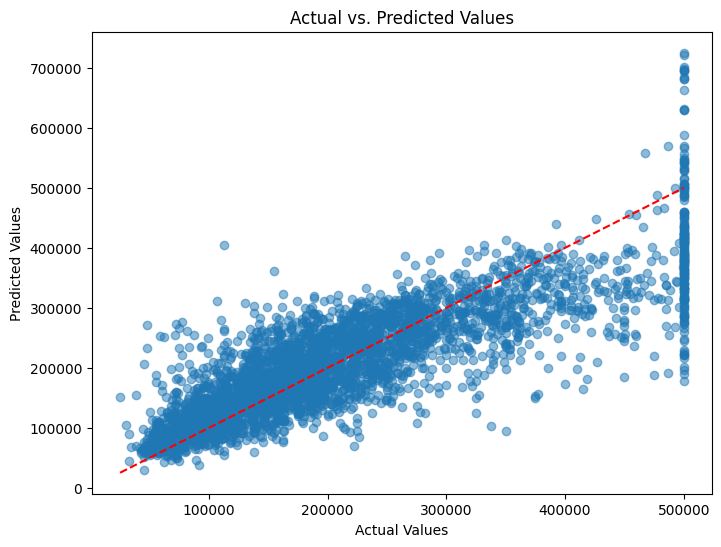

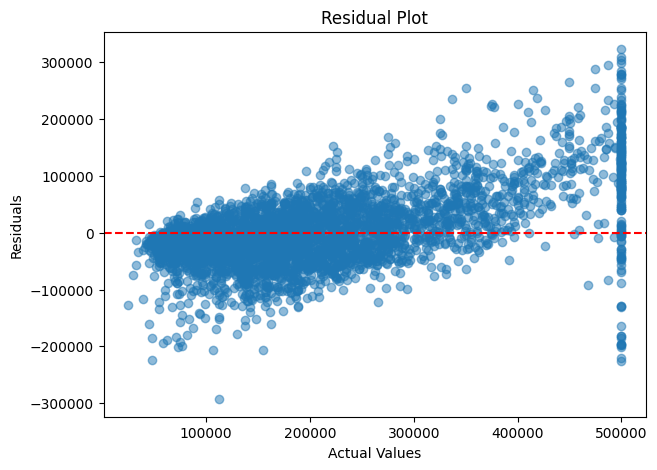

In [5]:
# Evaluate the model
# loss, mae = model.evaluate(X_test, y_test)
# print(f"Mean Absolute Error on test set: {mae}")
loss, rmse = model.evaluate(X_test, y_test)
print(f"Root Mean Squared Error on test set: {rmse}")
print(f"loss on test set: {loss}")

# Compare actual and predicted values using scatter plot
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()

# Reshape y_pred to be 1-dimensional
y_pred = y_pred.flatten()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='dashed')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Conclusion